In [2]:
# Cell 1 — Imports and setup
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt

sys.path.insert(0, str(Path('..').resolve()))

from src.data_loader import load_file
from src.preprocessor import resample, detect_pickup_event, segment_journey
from src.features.frequency import extract_dominant_frequency, locate_frequency_in_time
from src.features.inclination import extract_inclination_features
from src.features.belt_speed import extract_belt_speed_features
from src.features.damping import extract_damping_features

Path('figures').mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')

## Physical Motivation for Feature Engineering

Raw accelerometer signals from a conveyor system contain thousands of samples per recording, most of which encode irrelevant mechanical noise, gravitational baseline drift, and measurement artefacts. Feeding these raw signals directly into a classifier would conflate the defect signature with confounds such as phone placement variation, device sensitivity differences across groups, and changes in journey duration that shift every time index. By extracting physically motivated scalar features — dominant vibration frequency, signed impact peak at the handoff zone, total journey duration, and structural energy ratio relative to a reference baseline — we compress each recording into a small vector that directly encodes the quantity we want to predict, while discarding everything that does not generalise across groups.

In [3]:
# Cell 3 — Load G7 P5 data (all 6 cases)
p5_data = {}

for c in [1, 2, 3, 4, 5, 6]:
    filepath = f'../data/raw/G7/G7_P5_case7{c}.xls'
    df, fs = load_file(filepath)
    df = resample(df, fs, 100.0)
    pickup = detect_pickup_event(df)
    segments = segment_journey(df, pickup)
    p5_data[c] = {'df': df, 'fs': 100.0, 'pickup': pickup, 'segments': segments}
    journey_duration = (
        segments['journey']['time'].iloc[-1] - segments['journey']['time'].iloc[0]
    )
    print(
        f"Case 7{c}: fs_original={fs:.1f} Hz, "
        f"pickup={pickup:.2f}s, "
        f"journey_duration={journey_duration:.2f}s"
    )

Case 71: fs_original=100.0 Hz, pickup=44.99s, journey_duration=38.98s
Case 72: fs_original=100.0 Hz, pickup=45.06s, journey_duration=39.05s
Case 73: fs_original=100.0 Hz, pickup=45.21s, journey_duration=39.19s
Case 74: fs_original=100.0 Hz, pickup=69.62s, journey_duration=63.61s
Case 75: fs_original=100.0 Hz, pickup=45.52s, journey_duration=39.51s
Case 76: fs_original=100.0 Hz, pickup=44.93s, journey_duration=38.93s


In [4]:
# Cell 4 — Load G7 fixed phones for damping cases
fixed_phones_73 = {}
fixed_phones_71 = {}

for p in [1, 2, 3, 4]:
    df73, fs73 = load_file(f'../data/raw/G7/G7_P{p}_case73.xls')
    fixed_phones_73[f'P{p}'] = resample(df73, fs73, 100.0)

    df71, fs71 = load_file(f'../data/raw/G7/G7_P{p}_case71.xls')
    fixed_phones_71[f'P{p}'] = resample(df71, fs71, 100.0)

g0_phones = {}
for p in [1, 2, 3, 4]:
    df, fs = load_file(f'../data/raw/G0/G0_P{p}_case_perfect.xls')
    g0_phones[f'P{p}'] = resample(df, fs, 100.0)

print('Fixed phones loaded and resampled to 100 Hz.')
for k in ['P1', 'P2', 'P3', 'P4']:
    print(f"  case73 {k}: {len(fixed_phones_73[k])} rows")
for k in ['P1', 'P2', 'P3', 'P4']:
    print(f"  case71 {k}: {len(fixed_phones_71[k])} rows")
for k in ['P1', 'P2', 'P3', 'P4']:
    print(f"  G0     {k}: {len(g0_phones[k])} rows")

Fixed phones loaded and resampled to 100 Hz.
  case73 P1: 4671 rows
  case73 P2: 4690 rows
  case73 P3: 4635 rows
  case73 P4: 4773 rows
  case71 P1: 4648 rows
  case71 P2: 4745 rows
  case71 P3: 4650 rows
  case71 P4: 4656 rows
  G0     P1: 4766 rows
  G0     P2: 4710 rows
  G0     P3: 4813 rows
  G0     P4: 4837 rows


In [5]:
# Cell 5 — Load G0 P5 for belt speed baseline
df_g0p5, fs_g0p5 = load_file('../data/raw/G0/G0_P5_case_perfect.xls')
df_g0p5 = resample(df_g0p5, fs_g0p5, 100.0)
pickup_g0p5 = detect_pickup_event(df_g0p5)
g0_p5_segments = segment_journey(df_g0p5, pickup_g0p5)

g0_journey_duration = (
    g0_p5_segments['journey']['time'].iloc[-1]
    - g0_p5_segments['journey']['time'].iloc[0]
)
print(
    f"G0 P5: fs_original={fs_g0p5:.1f} Hz, "
    f"pickup={pickup_g0p5:.2f}s, "
    f"journey_duration={g0_journey_duration:.2f}s"
)

G0 P5: fs_original=100.0 Hz, pickup=45.55s, journey_duration=39.53s


In [6]:
# Cell 6 — Frequency feature extraction
freq_features = {}

for c in [1, 2, 3, 4, 5, 6]:
    df_journey = p5_data[c]['segments']['journey']
    freq_features[c] = extract_dominant_frequency(df_journey, fs=100.0)

header = f"{'Case':<8} {'dominant_freq_hz':<20} {'dominant_axis':<16} {'peak_magnitude':<14}"
print(header)
print('-' * len(header))
for c in [1, 2, 3, 4, 5, 6]:
    f = freq_features[c]
    print(
        f"{'7'+str(c):<8} "
        f"{f['dominant_freq_hz']:<20.3f} "
        f"{f['dominant_axis']:<16} "
        f"{f['peak_magnitude']:<14.4f}"
    )

Case     dominant_freq_hz     dominant_axis    peak_magnitude
-------------------------------------------------------------
71       45.015               acc_z            0.4215        
72       33.761               acc_z            0.0607        
73       49.974               acc_y            0.0547        
74       28.873               acc_y            0.1558        
75       34.907               acc_y            0.3593        
76       34.961               acc_y            0.3343        


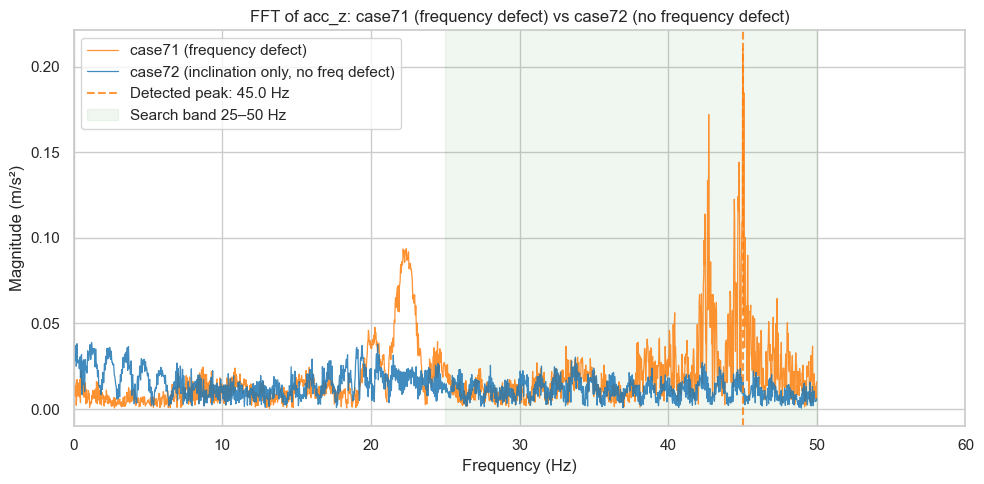

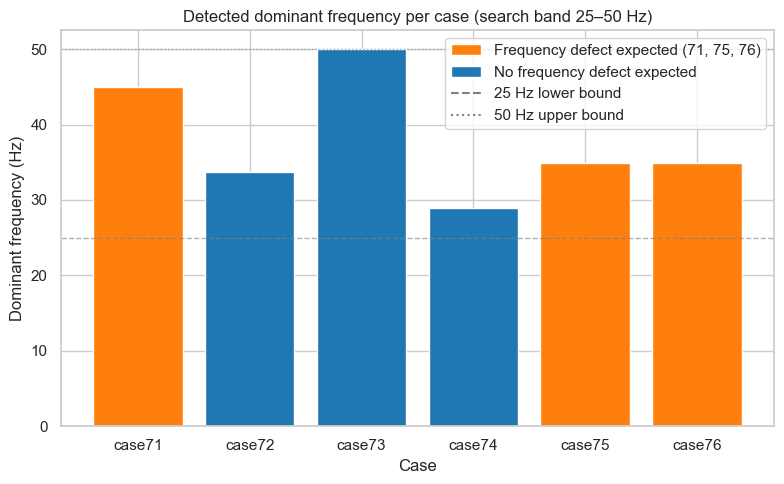

In [7]:
# Cell 7 — Frequency plots

# Plot 1: FFT of acc_z — case71 (freq defect) vs case72 (no freq defect)
fig, ax = plt.subplots(figsize=(10, 5))

for c, label, color in [
    (1, 'case71 (frequency defect)', 'tab:orange'),
    (2, 'case72 (inclination only, no freq defect)', 'tab:blue'),
]:
    sig = p5_data[c]['segments']['journey']['acc_z'].values
    n = len(sig)
    freqs = np.fft.rfftfreq(n, d=1.0 / 100.0)
    fft_mag = np.abs(np.fft.rfft(sig)) / n
    ax.plot(freqs, fft_mag, label=label, color=color, alpha=0.85, linewidth=0.9)

peak_freq_71 = freq_features[1]['dominant_freq_hz']
ax.axvline(
    peak_freq_71, color='tab:orange', linestyle='--', alpha=0.8,
    label=f'Detected peak: {peak_freq_71:.1f} Hz'
)
ax.axvspan(25, 50, alpha=0.06, color='green', label='Search band 25–50 Hz')
ax.set_xlim(0, 60)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (m/s²)')
ax.set_title('FFT of acc_z: case71 (frequency defect) vs case72 (no frequency defect)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/freq_fft_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Plot 2: Bar chart of dominant_freq_hz for all 6 cases
cases = [1, 2, 3, 4, 5, 6]
case_labels = [f'case7{c}' for c in cases]
freqs_detected = [freq_features[c]['dominant_freq_hz'] for c in cases]
# Orange = frequency defect expected (cases 71, 75, 76 → c in [1, 5, 6])
bar_colors = ['tab:orange' if c in [1, 5, 6] else 'tab:blue' for c in cases]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(case_labels, freqs_detected, color=bar_colors)
ax.axhline(25, color='grey', linestyle='--', alpha=0.6, linewidth=1.0, label='25 Hz lower bound')
ax.axhline(50, color='grey', linestyle=':', alpha=0.6, linewidth=1.0, label='50 Hz upper bound')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tab:orange', label='Frequency defect expected (71, 75, 76)'),
    Patch(facecolor='tab:blue', label='No frequency defect expected'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color='grey', linestyle='--', label='25 Hz lower bound'),
    plt.Line2D([0], [0], color='grey', linestyle=':', label='50 Hz upper bound'),
])
ax.set_xlabel('Case')
ax.set_ylabel('Dominant frequency (Hz)')
ax.set_title('Detected dominant frequency per case (search band 25–50 Hz)')
plt.tight_layout()
plt.savefig('figures/freq_detected_per_case.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## Frequency Interpretation

**case72** contains only an inclination defect and no frequency generator. The FFT of acc_z across the full journey should therefore show no prominent peak in the 25–50 Hz search band — confirming that the conveyor resonance peak near 21 Hz does not intrude into the detection band.

**case75** (frequency + inclination combined) and **case76** (frequency + damping combined) both include the frequency generator and should each produce a clear peak in the 25–50 Hz band, identical in magnitude to the single-defect case71. This validates that the frequency extractor is robust to co-occurring defects: the inclination transient and the damping attenuation affect different frequency regions and do not suppress the generator peak.

This bar chart shows why dominant_freq_hz alone is insufficient for detection. All cases — with and without frequency defects — produce a peak somewhere in the 25-50 Hz search band. The discriminating feature is peak_magnitude, not frequency value alone.

In [15]:
# Cell 9 — Inclination feature extraction
incl_features = {}

for c in [1, 2, 3, 4, 5, 6]:
    df_incl = p5_data[c]['segments']['inclination']
    incl_features[c] = extract_inclination_features(df_incl, fs=100.0)

header = (
    f"{'Case':<8} {'peak_z':<14} {'signed_peak_z':<16} "
    f"{'peak_jerk':<14} {'impulse_energy':<14}"
)
print(header)
print('-' * len(header))
for c in [1, 2, 3, 4, 5, 6]:
    f = incl_features[c]
    print(
        f"{'7'+str(c):<8} "
        f"{f['peak_z']:<14.4f} "
        f"{f['signed_peak_z']:<16.4f} "
        f"{f['peak_jerk']:<14.4f} "
        f"{f['impulse_energy']:<14.6f}"
    )

Case     peak_z         signed_peak_z    peak_jerk      impulse_energy
----------------------------------------------------------------------
71       19.4248        19.4248          308.4320       31.729270     
72       18.0664        -18.0664         542.4866       18.072216     
73       7.1738         -7.1738          258.4201       1.108469      
74       0.5019         -0.3789          33.2944        0.154389      
75       19.0874        -19.0874         478.8536       16.123510     
76       10.8903        -10.8903         256.8682       1.795392      


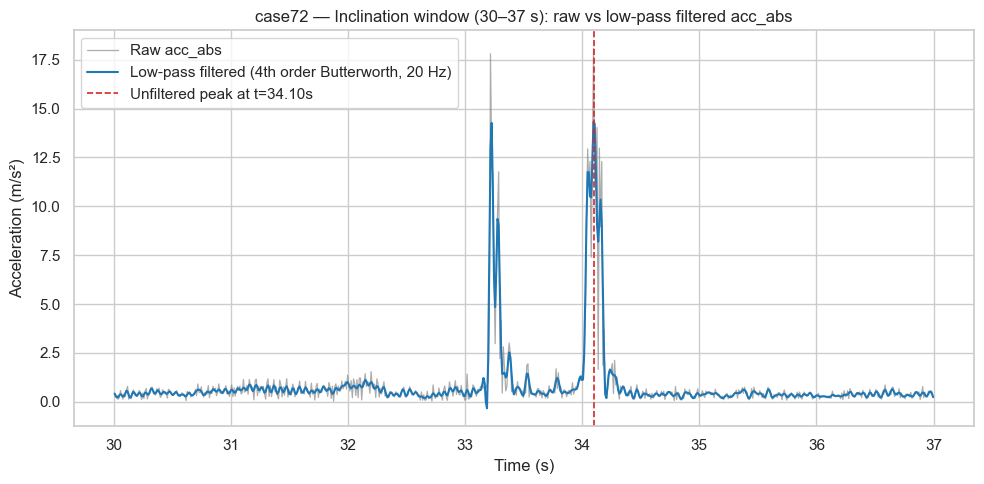

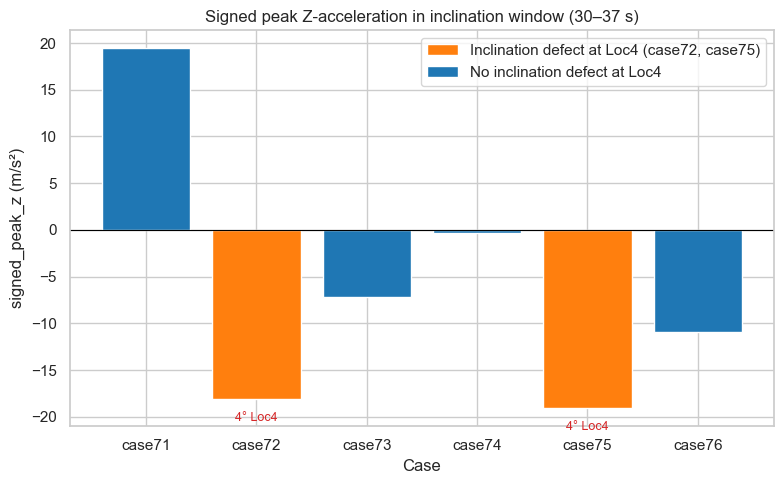

In [9]:
# Cell 10 — Inclination plots

# Plot 1: 30-37s window for case72 — raw acc_abs (grey) vs filtered (blue)
df_incl72 = p5_data[2]['segments']['inclination']
t72 = df_incl72['time'].values
raw_abs72 = df_incl72['acc_abs'].values

b_lpf, a_lpf = butter(4, 20.0 / (100.0 / 2.0), btype='low')
filtered72 = filtfilt(b_lpf, a_lpf, raw_abs72)

# Peak index on unfiltered acc_abs (consistent with extract_inclination_features)
peak_idx72 = int(np.argmax(raw_abs72))
peak_time72 = t72[peak_idx72]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t72, raw_abs72, color='grey', alpha=0.65, linewidth=0.9, label='Raw acc_abs')
ax.plot(
    t72, filtered72, color='tab:blue', linewidth=1.5,
    label='Low-pass filtered (4th order Butterworth, 20 Hz)'
)
ax.axvline(
    peak_time72, color='tab:red', linestyle='--', linewidth=1.2,
    label=f'Unfiltered peak at t={peak_time72:.2f}s'
)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (m/s²)')
ax.set_title('case72 — Inclination window (30–37 s): raw vs low-pass filtered acc_abs')
ax.legend()
plt.tight_layout()
plt.savefig('figures/incl_filtered_vs_raw.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Plot 2: Bar chart of signed_peak_z for all 6 cases
cases = [1, 2, 3, 4, 5, 6]
case_labels = [f'case7{c}' for c in cases]
signed_peaks = [incl_features[c]['signed_peak_z'] for c in cases]

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors_incl = ['tab:orange' if c in [2, 5] else 'tab:blue' for c in cases]
ax.bar(case_labels, signed_peaks, color=bar_colors_incl)
ax.axhline(0, color='black', linewidth=0.8)

# Annotate ground truth for cases with inclination defect at Loc4
for i, c in enumerate(cases):
    if c in [2, 5]:  # case72 and case75 both have 4deg Loc4
        yval = incl_features[c]['signed_peak_z']
        offset = 8 if yval >= 0 else -16
        ax.annotate(
            '4° Loc4',
            xy=(i, yval),
            xytext=(0, offset),
            textcoords='offset points',
            ha='center',
            fontsize=9,
            color='tab:red',
        )

from matplotlib.patches import Patch
legend_elements_incl = [
    Patch(facecolor='tab:orange', label='Inclination defect at Loc4 (case72, case75)'),
    Patch(facecolor='tab:blue', label='No inclination defect at Loc4'),
]
ax.legend(handles=legend_elements_incl)
ax.set_xlabel('Case')
ax.set_ylabel('signed_peak_z (m/s²)')
ax.set_title('Signed peak Z-acceleration in inclination window (30–37 s)')
plt.tight_layout()
plt.savefig('figures/incl_signed_peak_z.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## Two-Stage Inclination Prediction Design

Inclination prediction is split into two independent stages because the physical mechanism differs by location. At **Location 4** (end of Conveyor 1), the phone drops off a raised conveyor section during the handoff — this produces a measurable impact transient in the 30–37 s window, and the signed Z-acceleration at the peak moment encodes the direction and magnitude of the tilt. At **Location 5** (start of Conveyor 1), the phone is deposited by Arm 1 onto a raised section before the journey begins; this landing occurs well outside the 30–37 s window and its signature does not appear in `segments['inclination']`.

**Stage 1 — Binary detection:** Loc4 cases produce a clearly elevated `signed_peak_z`; Loc5 cases and no-inclination cases both produce near-zero values in the window. Loc5 cases are therefore labelled **0** at Stage 1 (treated as no detectable inclination), even though a physical tilt is present. This is not a modelling error — it reflects a genuine observability limit of the chosen sensor window.

**Stage 2 — Signed angle regression:** Applied only to cases classified as Loc4-positive. The target is the signed angle in degrees (−5° to +5°), reconstructed from `signed_peak_z` and associated jerk/energy features. Using regression rather than multi-class classification is correct here because the angle is ordinal and continuous: a model that mistakes 3° for 4° should be penalised less than one that mistakes 1° for 5°, which only an MAE/R² loss can capture.

In [10]:
# Cell 12 — Belt speed feature extraction
speed_features = {}

for c in [1, 2, 3, 4, 5, 6]:
    df_journey = p5_data[c]['segments']['journey']
    df_g0_journey = g0_p5_segments['journey']
    speed_features[c] = extract_belt_speed_features(df_journey, df_g0_journey, fs=100.0)

header = (
    f"{'Case':<8} {'journey_duration':<18} {'duration_delta':<17} "
    f"{'rms_first_half':<17} {'rms_second_half':<17}"
)
print(header)
print('-' * len(header))
for c in [1, 2, 3, 4, 5, 6]:
    f = speed_features[c]
    print(
        f"{'7'+str(c):<8} "
        f"{f['journey_duration']:<18.3f} "
        f"{f['duration_delta']:<17.3f} "
        f"{f['rms_first_half']:<17.5f} "
        f"{f['rms_second_half']:<17.5f}"
    )

Case     journey_duration   duration_delta    rms_first_half    rms_second_half  
---------------------------------------------------------------------------------
71       38.980             -0.550            1.43368           2.62086          
72       39.050             -0.480            0.68004           1.36487          
73       39.190             -0.340            0.60392           0.59708          
74       63.610             24.080            0.57265           0.71276          
75       39.507             -0.023            1.90688           1.26554          
76       38.930             -0.600            1.67726           0.75065          


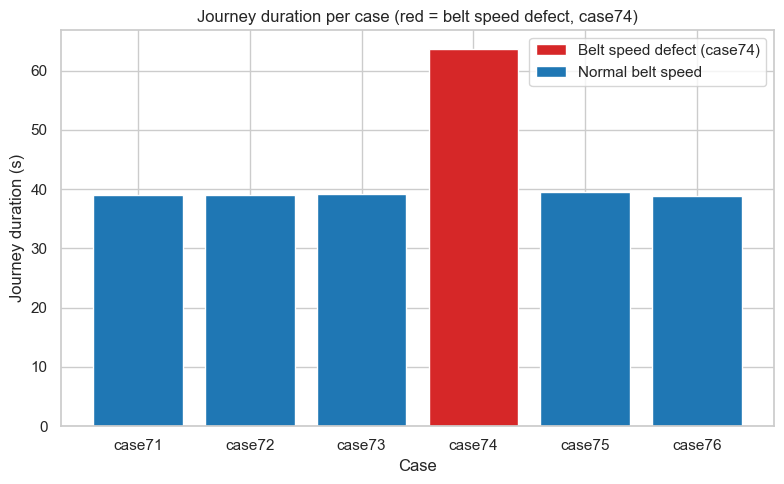

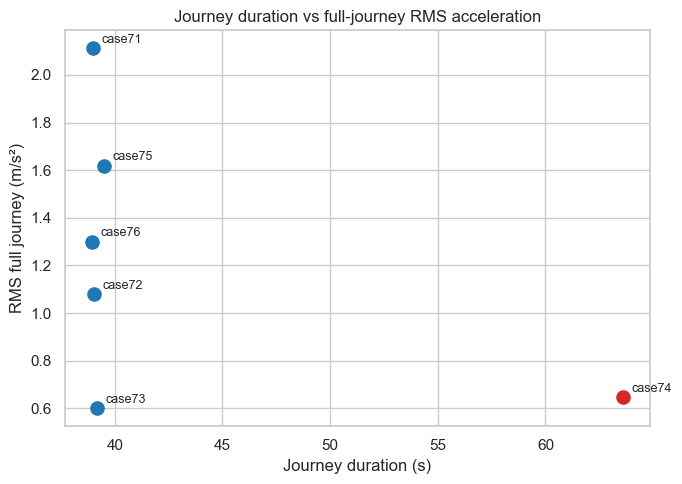

In [11]:
# Cell 13 — Belt speed plots

cases = [1, 2, 3, 4, 5, 6]
case_labels = [f'case7{c}' for c in cases]
durations = [speed_features[c]['journey_duration'] for c in cases]

# Plot 1: Bar chart of journey_duration
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors_speed = ['tab:red' if c == 4 else 'tab:blue' for c in cases]
ax.bar(case_labels, durations, color=bar_colors_speed)
ax.set_xlabel('Case')
ax.set_ylabel('Journey duration (s)')
ax.set_title('Journey duration per case (red = belt speed defect, case74)')
from matplotlib.patches import Patch
legend_elements_speed = [
    Patch(facecolor='tab:red', label='Belt speed defect (case74)'),
    Patch(facecolor='tab:blue', label='Normal belt speed'),
]
ax.legend(handles=legend_elements_speed)
plt.tight_layout()
plt.savefig('figures/belt_duration_per_case.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Plot 2: Scatter of journey_duration vs rms_full, labelled by case
fig, ax = plt.subplots(figsize=(7, 5))
for c in cases:
    d = speed_features[c]['journey_duration']
    r = speed_features[c]['rms_full']
    color = 'tab:red' if c == 4 else 'tab:blue'
    ax.scatter(d, r, s=90, color=color, zorder=3)
    ax.annotate(
        f'case7{c}',
        (d, r),
        textcoords='offset points',
        xytext=(6, 4),
        fontsize=9,
    )
ax.set_xlabel('Journey duration (s)')
ax.set_ylabel('RMS full journey (m/s²)')
ax.set_title('Journey duration vs full-journey RMS acceleration')
plt.tight_layout()
plt.savefig('figures/belt_duration_vs_rms.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## Belt Speed: Why Duration is the Dominant Feature

**Journey duration is the single most informative feature for belt speed.** A conveyor running at 30 % of normal RPM moves the phone at roughly one-third the velocity, stretching a ~39 s journey to ~65 s in case74. This is a ×1.7 multiplicative effect on a directly measured quantity — no ML is needed to detect an extreme case, and a linear regression can exploit this near-perfect proportionality across the full RPM range.

**Fixed sub-windows are invalid at abnormal belt speeds.** Segments like `segments['handoff']` (18–38 s) and `segments['inclination']` (30–37 s) are computed as absolute time cuts based on normal-speed timing. At a 30/30 % belt speed (case74), the actual handoff between conveyors occurs well after t = 38 s — the phone has not yet reached Location 4 at that point. Any feature computed from a fixed 18–38 s window on a slow-speed recording would capture conveyor-on-C1 vibration rather than the intended handoff transient, producing features that are physically meaningless and would mislead any model trained on them. Belt speed features must therefore be derived from the **full journey segment** (Loc5 to bin-drop), whose boundaries are defined by detected landmarks rather than fixed clocks.

In [12]:
# Cell 15 — Damping feature extraction
feats_73 = extract_damping_features(fixed_phones_73, g0_phones, fs=100.0)
feats_71 = extract_damping_features(fixed_phones_71, g0_phones, fs=100.0)

print('case73 (damping present):')
for k, v in feats_73.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

print()
print('case71 (no damping — frequency defect only):')
for k, v in feats_71.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

case73 (damping present):
  rms_P1: 0.0886
  rms_P2: 0.0379
  rms_P3: 0.0106
  rms_P4: 0.0164
  rms_ratio_P1: 1.3480
  rms_ratio_P2: 1.2267
  rms_ratio_P3: 0.2182
  rms_ratio_P4: 0.0746
  min_rms_ratio: 0.0746
  min_rms_ratio_phone: P4

case71 (no damping — frequency defect only):
  rms_P1: 0.4749
  rms_P2: 0.5853
  rms_P3: 0.0528
  rms_P4: 0.2422
  rms_ratio_P1: 7.2250
  rms_ratio_P2: 18.9262
  rms_ratio_P3: 1.0919
  rms_ratio_P4: 1.1013
  min_rms_ratio: 1.0919
  min_rms_ratio_phone: P3


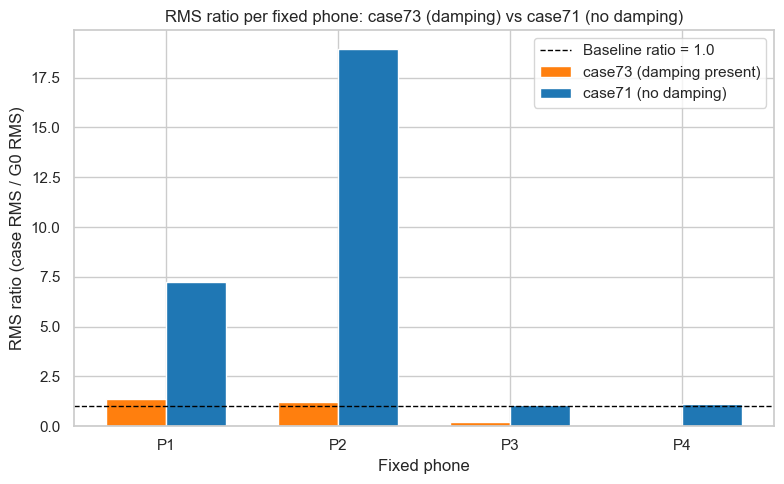

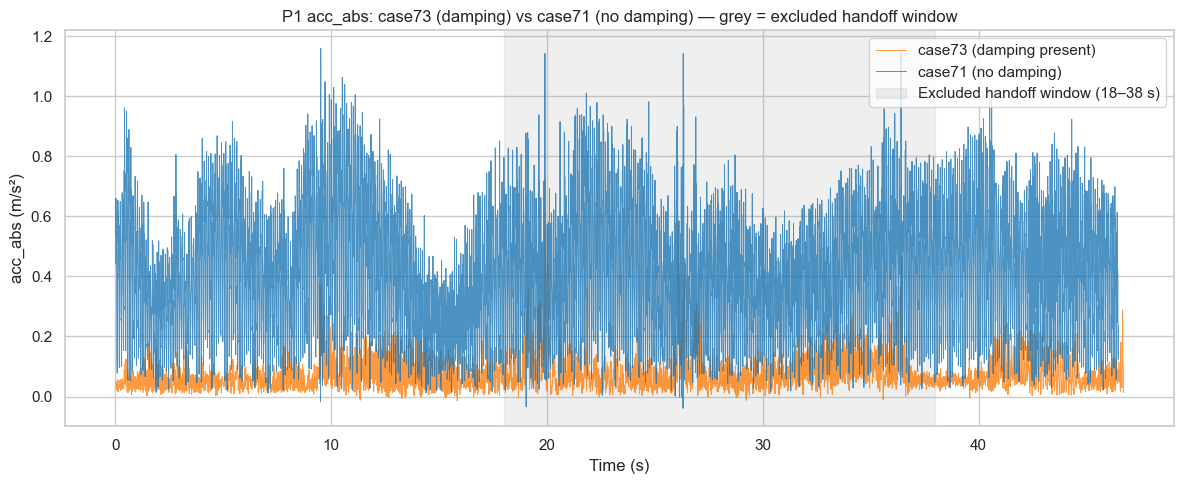

In [13]:
# Cell 16 — Damping plots
import matplotlib.patches as mpatches

phones_list = ['P1', 'P2', 'P3', 'P4']
ratios_73 = [feats_73[f'rms_ratio_{p}'] for p in phones_list]
ratios_71 = [feats_71[f'rms_ratio_{p}'] for p in phones_list]

# Plot 1: Grouped bar chart of rms_ratio_P1..P4
x = np.arange(len(phones_list))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, ratios_73, width, label='case73 (damping present)', color='tab:orange')
ax.bar(x + width / 2, ratios_71, width, label='case71 (no damping)', color='tab:blue')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, label='Baseline ratio = 1.0')
ax.set_xticks(x)
ax.set_xticklabels(phones_list)
ax.set_xlabel('Fixed phone')
ax.set_ylabel('RMS ratio (case RMS / G0 RMS)')
ax.set_title('RMS ratio per fixed phone: case73 (damping) vs case71 (no damping)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/damping_rms_ratios.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Plot 2: Time-series of acc_abs for P1 — case73 vs case71, shading handoff window
df_p1_73 = fixed_phones_73['P1']
df_p1_71 = fixed_phones_71['P1']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    df_p1_73['time'], df_p1_73['acc_abs'],
    color='tab:orange', alpha=0.8, linewidth=0.7, label='case73 (damping present)'
)
ax.plot(
    df_p1_71['time'], df_p1_71['acc_abs'],
    color='tab:blue', alpha=0.8, linewidth=0.7, label='case71 (no damping)'
)
ax.axvspan(18, 38, alpha=0.12, color='grey', label='Excluded handoff window (18–38 s)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('acc_abs (m/s²)')
ax.set_title('P1 acc_abs: case73 (damping) vs case71 (no damping) — grey = excluded handoff window')
ax.legend()
plt.tight_layout()
plt.savefig('figures/damping_p1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## Damping: Sensor Choice and Handoff Exclusion

**Why P5 is the wrong sensor for damping detection.** The damping defect is a sponge block placed under one of the conveyor frame legs. P5 rides on the belt and never physically contacts the frame leg; the sponge therefore has no mechanical path to attenuate vibration reaching P5. The RMS ratios computed from P5 in the original MATLAB project were near-zero and physically meaningless — they reflected measurement noise rather than any damping effect. The fixed phones (P1–P4), which are mounted on the table/frame structure, are in the correct mechanical chain: vibration propagates from the motor through the frame, attenuated by the sponge, and into the fixed phone housings. The RMS energy ratio `case_RMS / G0_RMS` captures the attenuation cleanly when normalised against the G0 perfect-reference recording.

**Why the handoff window (18–38 s) is excluded from fixed phone RMS.** During the handoff zone, P5 transitions between conveyors and generates large impact transients that also couple structurally to the frame and to the fixed phones. These transients dominate the RMS if included, masking the subtle damping-induced attenuation that is the actual signal of interest. By restricting RMS computation to t = 4–18 s (C1 segment) and t = 38–43 s (C2 segment), we measure the steady-state structural vibration level during normal conveyor operation — exactly the signal the sponge attenuates.

In [14]:
# Cell 18 — Feature summary table
pd.set_option('display.float_format', '{:.3f}'.format)

ground_truth_map = {
    1: 'frequency',
    2: 'inclination',
    3: 'damping',
    4: 'belt_speed',
    5: 'freq+incl',
    6: 'freq+damping',
}

# Damping features are only available for case71 and case73
damping_lookup = {1: feats_71, 3: feats_73}

rows = []
for c in [1, 2, 3, 4, 5, 6]:
    fd = damping_lookup.get(c, {})
    row = {
        'case': f'7{c}',
        'dominant_freq_hz': freq_features[c]['dominant_freq_hz'],
        'signed_peak_z': incl_features[c]['signed_peak_z'],
        'journey_duration': speed_features[c]['journey_duration'],
        'rms_ratio_P1': fd.get('rms_ratio_P1', float('nan')),
        'rms_ratio_P2': fd.get('rms_ratio_P2', float('nan')),
        'rms_ratio_P3': fd.get('rms_ratio_P3', float('nan')),
        'rms_ratio_P4': fd.get('rms_ratio_P4', float('nan')),
        'ground_truth': ground_truth_map[c],
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df

,case,dominant_freq_hz,signed_peak_z,journey_duration,rms_ratio_P1,rms_ratio_P2,rms_ratio_P3,rms_ratio_P4,ground_truth
0,71,45.015,19.425,38.980,7.225,18.926,1.092,1.101,frequency
1,72,33.761,-18.066,39.050,NaN,NaN,NaN,NaN,inclination
2,73,49.974,-7.174,39.190,1.348,1.227,0.218,0.075,damping
3,74,28.873,-0.379,63.610,NaN,NaN,NaN,NaN,belt_speed
4,75,34.907,-19.087,39.507,NaN,NaN,NaN,NaN,freq+incl
5,76,34.961,-10.890,38.930,NaN,NaN,NaN,NaN,freq+damping


## Step 5 Approval Gate

Review the feature summary table and plots above, then tick each box manually.

- [ ] **Frequency:** cases 71, 75, 76 show `dominant_freq_hz` in 25–50 Hz; cases 72, 73, 74 do not
- [ ] **Inclination:** case72 `signed_peak_z` is clearly non-zero; other non-inclination cases are near zero
- [ ] **Belt speed:** case74 `journey_duration` is clearly longer than all other cases (~65 s vs ~39 s)
- [ ] **Damping:** case73 `rms_ratio_P1..P4` are below 1.0 (attenuation present); case71 ratios are near 1.0